# Case 985 BESTEST validation

Native ISO is the formal ASHRAE 140 result. `modelica_solar` is a controlled-forcing comparative run and is not a formal result.

In [1]:
CASE="985"
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ISO_MODE = "modelica_solar"  # "modelica_solar" or "native"
root = Path.cwd()
if not (root / "scripts").is_dir(): root = root.parent
sys.path.insert(0, str(root / "scripts"))
from bestest_iso_reporting import annual_energy_table, completed_hour_label, markdown_table, selected_iso_mode
from bestest_iso_case9xx_reporting import annual_tracks, comparison_table, peak_tracks, prescribed_changes, range_judgement
case = CASE
out = root / "results" / f"case{case}"
reference = root / "_ref" / "BESTEST_LBNL_all_cases_reference.md"
metrics = pd.read_csv(out / f"case{case}_metrics.csv")
solar = pd.read_csv(out / f"case{case}_solar_comparison.csv")
references = pd.concat([pd.DataFrame([{"case": r.Case, "metric": metric, "lower": float(r.Lower), "upper": float(r.Upper)} for _, r in markdown_table(reference, section).iterrows()]) for section, metric in (("Annual heating energy reference data", "annual_heating_energy"), ("Annual cooling energy reference data", "annual_cooling_energy"))], ignore_index=True)
_, ISO_LABEL = selected_iso_mode(ISO_MODE)

## 1. Case definition

Case 985 inherits Case 600 with these explicit BESTEST changes:

- heating setpoint: 19.9 C
- cooling setpoint: 20.1 C

Weather: Denver TMY3; non-leap calendar; simulation/output timestep: 1 h.

In [2]:
display(prescribed_changes(case)); base=json.loads((root/'inputs'/'1_iso'/'case900.json').read_text()); display(pd.DataFrame([{"Geometry":f"{base['geometry']['floor_area_m2']} m² floor; {base['geometry']['volume_m3']} m³ volume","Construction":base['constructions']['mass_class'],"Weather":base['weather']['identifier'],"Timestep":"1 h"}])); display(pd.read_csv(root/'inputs'/'1_iso'/'case900_adapter_mapping.csv')[['quantity','ashrae_value','ashrae_unit','modelica_parameter','iso_parameter','mapping_type']])

,case,prescribed_change
0,985,heating setpoint: 19.9 C
1,985,cooling setpoint: 20.1 C


,Geometry,Construction,Weather,Timestep
0,48.0 m² floor; 129.6 m³ volume,heavyweight,USA_CO_Denver.Intl.AP.725650_TMY3,1 h


,quantity,ashrae_value,ashrae_unit,modelica_parameter,iso_parameter,mapping_type
0,floor area,48,m2,zonHVAC.AFlo,Zone.floor_area,direct
1,room volume,129.6,m3,zonHVAC.VRoo,Zone.room_vol,direct
2,south window area,12,m2,zonHVAC.AWin[3],Zone.window_area,direct
3,wall/roof/floor U-values,0.53/0.33/0.038,W/m2K,zonHVAC.UWal/URoo/UFlo,Zone aggregate opaque UA,aggregated
4,window U-value and g-value,3.1/0.769,W/m2K/-,zonHVAC.UWin/gFac,Zone.u_windows/Window.glass_solar_transmittance,direct
5,thermal mass capacity,307750,J/m2K,buiMas.heaC,Zone.thermal_capacitance_per_floor_area,direct
6,effective mass area factor,2.43,m2/m2,buiMas.facMas,Zone.effective_mass_area_per_floor_area,direct
7,infiltration,0.414,1/h,zonHVAC.airRat,Zone.h_ve_adj,derived
8,internal sensible gain,200,W,intGai.k,Zone.solve_energy,direct
9,setpoints,20/27,degC,TSetHea/TSetCoo,Zone.t_set_heating/t_set_cooling,direct


## 2. Annual heating and cooling

Three computed tracks, MWh.

In [3]:
display(annual_tracks(metrics))

,Run,Heating MWh,Cooling MWh
0,Native ISO,4.828186,2.521523
1,ISO + Modelica solar,2.309594,5.897670
2,Modelica native,2.332906,5.905086


## 3. Annual energy validation outcome

Formal annual-energy judgement for native ISO only.

In [4]:
display(range_judgement(metrics,references,case))

,Metric,Native ISO MWh,ASHRAE lower MWh,ASHRAE upper MWh,Distance to violated bound MWh,Distance %,Formal status
0,Heating,4.828186,1.68,3.09,1.738186,56.251965,FAIL
1,Cooling,2.521523,5.95,7.26,-3.428477,-57.621454,FAIL


## 4. Annual heating figure

Annual heating energy with published ASHRAE limits.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,985,1.68,3.09,2.801,2.12,2.279,2.369,2.283,2.536,2.332906,2.309594,PASS — diagnostic


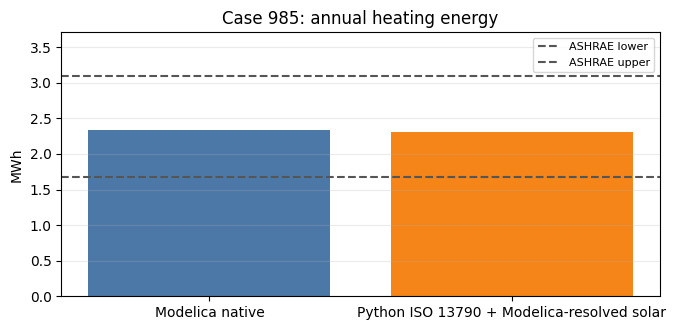

In [5]:
table=annual_energy_table(metrics, reference, case, "annual_heating_energy", ISO_MODE)
display(table)
row=table.iloc[0]; labels=["Modelica native", ISO_LABEL]; values=[row["Modelica native"],row[ISO_LABEL]]
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(labels,values,color=["#4C78A8","#F58518"])
ax.axhline(row["ASHRAE lower"],color="#555",linestyle="--",label="ASHRAE lower"); ax.axhline(row["ASHRAE upper"],color="#555",linestyle="--",label="ASHRAE upper")
ax.set(title=f"Case {case}: annual heating energy",ylabel="MWh",ylim=(0,max(values+[row["ASHRAE upper"]])*1.2)); ax.legend(fontsize=8); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 5. Annual cooling figure

Annual cooling energy with published ASHRAE limits.

,Case,ASHRAE lower,ASHRAE upper,BSIMAC,CSE,DeST,EnergyPlus,ESP-r,TRNSYS,Modelica native,Python ISO 13790 + Modelica-resolved solar,Python range status
0,985,5.95,7.26,7.273,6.234,5.88,6.359,6.249,6.113,5.905086,5.89767,FAIL — diagnostic


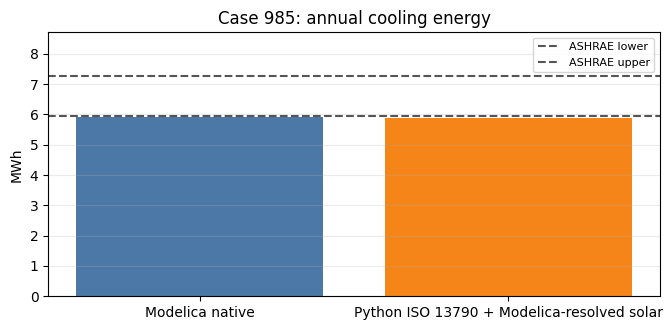

In [6]:
table=annual_energy_table(metrics, reference, case, "annual_cooling_energy", ISO_MODE)
display(table)
row=table.iloc[0]; labels=["Modelica native", ISO_LABEL]; values=[row["Modelica native"],row[ISO_LABEL]]
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(labels,values,color=["#4C78A8","#F58518"])
ax.axhline(row["ASHRAE lower"],color="#555",linestyle="--",label="ASHRAE lower"); ax.axhline(row["ASHRAE upper"],color="#555",linestyle="--",label="ASHRAE upper")
ax.set(title=f"Case {case}: annual cooling energy",ylabel="MWh",ylim=(0,max(values+[row["ASHRAE upper"]])*1.2)); ax.legend(fontsize=8); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 6. Peak heating and cooling

Computed peak loads and completed-hour occurrence times.

In [7]:
display(peak_tracks(metrics,completed_hour_label))

,Track,Peak heating kW,Peak heating time,Peak cooling kW,Peak cooling time
0,Modelica native,2.634994,09-Feb:06,3.052292,01-Oct:15
1,Native ISO,2.735191,09-Feb:06,1.970444,14-Jun:18
2,ISO + Modelica solar,2.641420,09-Feb:06,3.055590,01-Oct:15


## 7. Peak-load comparison figures

Computed peak loads, kW.

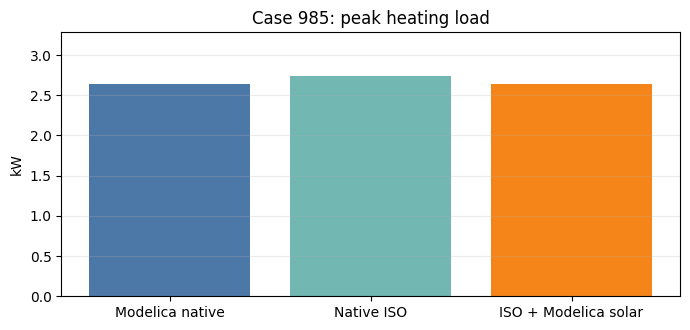

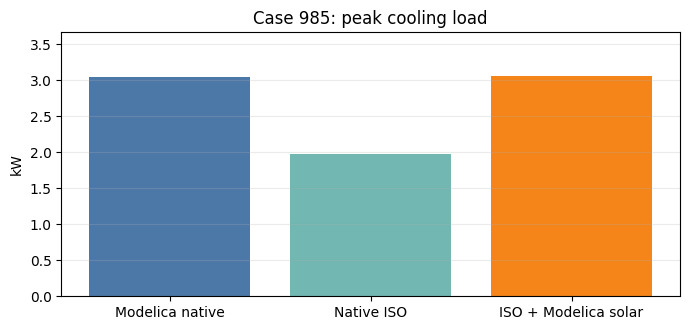

In [8]:
peaks=peak_tracks(metrics, completed_hour_label)
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(peaks["Track"],peaks["Peak heating kW"],color=["#4C78A8","#72B7B2","#F58518"])
ax.set(title=f"Case {case}: peak heating load",ylabel="kW",ylim=(0,peaks["Peak heating kW"].max()*1.2 if peaks["Peak heating kW"].max() else 1)); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()
peaks=peak_tracks(metrics, completed_hour_label)
fig,ax=plt.subplots(figsize=(7,3.4)); ax.bar(peaks["Track"],peaks["Peak cooling kW"],color=["#4C78A8","#72B7B2","#F58518"])
ax.set(title=f"Case {case}: peak cooling load",ylabel="kW",ylim=(0,peaks["Peak cooling kW"].max()*1.2 if peaks["Peak cooling kW"].max() else 1)); ax.grid(axis="y",alpha=.25); fig.tight_layout(); plt.show()

## 8. Daily load profile

The LBNL presentation requires daily load profiles only for Cases 600 and 900; none is added for this 6XX case.

## 9. Solar forcing

Annual zone-solar totals, MWh.

In [9]:
solar_report=solar.set_index('quantity').T; solar_report['Absolute difference MWh']=(solar_report['native_rclib_zone_solar_MWh']-solar_report['modelica_resolved_zone_solar_MWh']).abs(); solar_report['Relative difference %']=(solar_report['native_modelica_ratio']-1)*100; display(solar_report.reset_index(drop=True))

quantity,native_rclib_zone_solar_MWh,modelica_resolved_zone_solar_MWh,native_modelica_ratio,Absolute difference MWh,Relative difference %
0,4.270377,12.112389,0.352563,7.842012,-64.743724


## 10. Controlled-forcing agreement

ISO + Modelica solar minus Modelica native; diagnostic only.

In [10]:
display(comparison_table(metrics,"controlled_modelica"))

,Metric,Unit,Modelica,ISO + Modelica solar,Difference,Difference %
0,Annual heating,MWh,2.332906,2.309594,-0.023312,-0.999273
1,Annual cooling,MWh,5.905086,5.897670,-0.007417,-0.125597
2,Peak heating,kW,2.634994,2.641420,0.006426,0.243887
3,Peak cooling,kW,3.052292,3.055590,0.003298,0.108061


## 11. Native versus controlled-forcing effect

Effect of changing only solar forcing in ISO.

In [11]:
display(comparison_table(metrics,"solar_effect").query("Metric in ['Annual heating', 'Annual cooling']"))

,Metric,Unit,Native ISO,ISO + Modelica solar,Difference,Difference %
0,Annual heating,MWh,4.828186,2.309594,-2.518591,-52.164344
1,Annual cooling,MWh,2.521523,5.897670,3.376146,133.893108


## 12. Final case outcome

Concise formal-native and controlled-forcing record.

In [12]:
judgement=range_judgement(metrics,references,case); summary=annual_tracks(metrics).set_index('Run'); summary['Formal ASHRAE status']=['; '.join(judgement['Formal status']),'diagnostic','reference implementation']; display(summary.reset_index()); print('Native ISO formal annual status:','; '.join(judgement['Formal status'])); print('Controlled forcing remains a Modelica-comparative diagnostic; no new schema or timestamp mapping is introduced.')

,Run,Heating MWh,Cooling MWh,Formal ASHRAE status
0,Native ISO,4.828186,2.521523,FAIL; FAIL
1,ISO + Modelica solar,2.309594,5.897670,diagnostic
2,Modelica native,2.332906,5.905086,reference implementation


Native ISO formal annual status: FAIL; FAIL
Controlled forcing remains a Modelica-comparative diagnostic; no new schema or timestamp mapping is introduced.
